In [1]:
# ================================================================
# PART 1/3 — COLAB SETUP + UPLOAD 2 DATA FILES + DATA LOADING
# ================================================================

# If install fails once in Colab, rerun this cell.
!pip -q install imbalanced-learn xgboost shap torch-geometric

import os
import glob
import zipfile
import random
import warnings
import time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    cohen_kappa_score,
    roc_curve,
    precision_recall_curve,
)

from imblearn.over_sampling import BorderlineSMOTE
from scipy.stats import ttest_rel, wilcoxon
import xgboost as xgb

try:
    import shap
except ImportError:
    shap = None

try:
    from torch_geometric.nn import GATv2Conv, LayerNorm as GeoLayerNorm
except ImportError as e:
    raise ImportError(
        "torch-geometric installation failed. Rerun this cell once in Colab."
    ) from e

from google.colab import files

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[SYSTEM] device = {DEVICE}")

OUTPUT_DIR = "/content/benchmark_outputs"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

CONFIG = {
    "n_seeds": 5,
    "n_ablation_seeds": 3,
    "teacher_epochs": 220,
    "student_epochs": 220,
    "patience": 20,
    "teacher_lr": 1e-3,
    "student_lr": 1e-3,
    "teacher_wd": 1e-2,
    "student_wd": 1e-3,
    "batch_size": 128,
    "k_neighbors": 16,
    "robustness_k_values": [8, 16, 24],
    "smote_k_neighbors": 5,
    "smote_m_neighbors": 10,
    "te_splits": 5,
    "target_encoding_smoothing": 10,
    "test_size": 0.20,
    "val_size_within_trainval": 0.20,
    "label_smoothing": 0.05,
    "kd_temperature": 3.0,
    "kd_alpha": 0.40,
    "kd_beta": 0.20,
    "random_seeds": [0, 1, 2, 3, 4],
}

METRIC_NAMES = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "ROC-AUC", "PR-AUC", "MCC", "Bal-Acc", "Kappa"
]
PRIMARY_METRIC = "PR-AUC"


@dataclass
class DatasetBundle:
    name: str
    df: pd.DataFrame
    cont_cols: List[str]
    cat_cols: List[str]
    source_path: str
    label_col_used: str


@dataclass
class SplitBundle:
    Xtr: np.ndarray
    ytr: np.ndarray
    Xva: np.ndarray
    yva: np.ndarray
    Xte: np.ndarray
    yte: np.ndarray
    Xtr_b: np.ndarray
    ytr_b: np.ndarray
    feature_names: List[str]


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def metric_index(metric_name: str) -> int:
    return METRIC_NAMES.index(metric_name)


def safe_wilcoxon(a: np.ndarray, b: np.ndarray) -> float:
    try:
        return wilcoxon(a, b).pvalue
    except ValueError:
        return np.nan


def format_mean_std(arr: np.ndarray) -> str:
    return f"{arr.mean():.4f} ± {arr.std(ddof=0):.4f}"


def save_dataframe(df: pd.DataFrame, out_csv: str):
    df.to_csv(out_csv, index=True)
    print(f"[SAVED] {out_csv}")


def extract_csv_if_needed(uploaded_path: str, dataset_name: str) -> str:
    if uploaded_path.lower().endswith(".zip"):
        extract_dir = f"/content/extracted_{dataset_name}"
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(uploaded_path, "r") as z:
            z.extractall(extract_dir)
        csv_files = glob.glob(os.path.join(extract_dir, "**", "*.csv"), recursive=True)
        if len(csv_files) == 0:
            raise FileNotFoundError(f"No CSV file found inside zip: {uploaded_path}")
        print(f"[ZIP] Extracted CSV for {dataset_name}: {csv_files[0]}")
        return csv_files[0]
    return uploaded_path


def detect_label_column(df: pd.DataFrame, preferred: Optional[str] = None) -> str:
    cols = df.columns.tolist()
    lowered = {c.lower(): c for c in cols}

    if preferred is not None and preferred in cols:
        return preferred
    if preferred is not None and preferred.lower() in lowered:
        return lowered[preferred.lower()]

    candidates = ["class", "label", "is_fraud", "fraud", "target", "y", "labels"]
    for cand in candidates:
        if cand.lower() in lowered:
            return lowered[cand.lower()]

    print("Available columns:")
    print(cols)
    raise ValueError("Could not auto-detect the label column. Check the printed columns.")


def normalize_binary_target(series: pd.Series) -> pd.Series:
    positive_values = {"1", "true", "fraud", "fraudulent", "yes", "positive", "fake"}
    return series.astype(str).str.strip().str.lower().isin(positive_values).astype(int)


def load_uploaded_dataset(
    uploaded_path: str,
    dataset_name: str,
    preferred_label: Optional[str] = None,
    drop_columns_contains: Optional[List[str]] = None,
) -> DatasetBundle:
    drop_columns_contains = drop_columns_contains or ["url", "domain_name", "shop_name", "index", "unnamed"]

    csv_path = extract_csv_if_needed(uploaded_path, dataset_name)
    df = pd.read_csv(csv_path)
    print(f"\n[LOAD] {dataset_name} from {csv_path} shape={df.shape}")

    label_col = detect_label_column(df, preferred=preferred_label)
    df["y"] = normalize_binary_target(df[label_col])
    df = df.drop(columns=[label_col])

    drop_cols = []
    for c in df.columns:
        cl = c.lower()
        if any(tok in cl for tok in drop_columns_contains):
            drop_cols.append(c)
    df = df.drop(columns=drop_cols, errors="ignore")
    df = df.drop_duplicates().reset_index(drop=True)

    cont_cols, cat_cols = [], []
    for c in df.columns:
        if c == "y":
            continue
        if df[c].dtype.kind in "fi" and df[c].nunique(dropna=True) > 10:
            cont_cols.append(c)
        else:
            cat_cols.append(c)

    for c in cont_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

    for c in cat_cols:
        df[c] = df[c].astype(str)
        df[c] = df[c].fillna("missing")
        if not df[c].mode().empty:
            df[c] = df[c].replace("nan", df[c].mode()[0])

    print(
        f"[DATA] {dataset_name} rows={len(df)} fraud_rate={df['y'].mean():.3%} "
        f"cont={len(cont_cols)} cat={len(cat_cols)} label={label_col}"
    )

    return DatasetBundle(
        name=dataset_name,
        df=df,
        cont_cols=cont_cols,
        cat_cols=cat_cols,
        source_path=csv_path,
        label_col_used=label_col,
    )


# ------------------------------------------------
# UPLOAD THE TWO FILES
# ------------------------------------------------
print("\nUpload 1/2: creditcard.csv.zip")
up1 = files.upload()
file1 = list(up1.keys())[0]
file1_path = f"/content/{file1}"
print(f"[UPLOADED] First file: {file1_path}")

print("\nUpload 2/2: Fraudulent_online_shops_dataset (1).csv")
up2 = files.upload()
file2 = list(up2.keys())[0]
file2_path = f"/content/{file2}"
print(f"[UPLOADED] Second file: {file2_path}")


# ------------------------------------------------
# LOAD BOTH DATASETS
# ------------------------------------------------
creditcard_bundle = load_uploaded_dataset(
    uploaded_path=file1_path,
    dataset_name="creditcard_dataset",
    preferred_label="Class",
)

shops_bundle = load_uploaded_dataset(
    uploaded_path=file2_path,
    dataset_name="fraudulent_online_shops",
    preferred_label=None,
)

DATASET_BUNDLES = [creditcard_bundle, shops_bundle]

print("\n[READY] Both datasets loaded successfully.")
for b in DATASET_BUNDLES:
    print(f"- {b.name}: source={b.source_path}, label={b.label_col_used}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.6 MB/s eta 0:00:00
[SYSTEM] device = cuda

Upload 1/2: creditcard.csv.zip


KeyboardInterrupt: 

In [ ]:
# ================================================================
# PART 2/3 — PREPROCESSING + GRAPH + MODELS + TRAINING UTILS
# ================================================================


def oof_target_encode(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cat_cols: List[str],
    seed: int,
    n_splits: int,
    smoothing: float,
):
    global_mean = train_df["y"].mean()
    train_enc, val_enc, test_enc = train_df.copy(), val_df.copy(), test_df.copy()

    if len(cat_cols) == 0:
        return train_enc, val_enc, test_enc

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in cat_cols:
        oof = np.zeros(len(train_df), dtype=np.float32)
        for tr_idx, ho_idx in skf.split(train_df, train_df["y"]):
            fold_tr = train_df.iloc[tr_idx]
            stats = fold_tr.groupby(col)["y"].agg(["count", "mean"])
            mapping = ((stats["count"] * stats["mean"] + smoothing * global_mean) /
                       (stats["count"] + smoothing)).to_dict()
            oof[ho_idx] = train_df.iloc[ho_idx][col].map(mapping).fillna(global_mean).values

        train_enc[col] = oof

        full_stats = train_df.groupby(col)["y"].agg(["count", "mean"])
        full_map = ((full_stats["count"] * full_stats["mean"] + smoothing * global_mean) /
                    (full_stats["count"] + smoothing)).to_dict()
        val_enc[col] = val_df[col].map(full_map).fillna(global_mean)
        test_enc[col] = test_df[col].map(full_map).fillna(global_mean)

    return train_enc, val_enc, test_enc


def prepare_split(bundle: DatasetBundle, seed: int) -> SplitBundle:
    df = bundle.df.copy()

    trainval_df, test_df = train_test_split(
        df,
        test_size=CONFIG["test_size"],
        stratify=df["y"],
        random_state=seed,
    )
    train_df, val_df = train_test_split(
        trainval_df,
        test_size=CONFIG["val_size_within_trainval"],
        stratify=trainval_df["y"],
        random_state=seed,
    )

    train_df, val_df, test_df = oof_target_encode(
        train_df,
        val_df,
        test_df,
        bundle.cat_cols,
        seed,
        CONFIG["te_splits"],
        CONFIG["target_encoding_smoothing"],
    )

    feature_names = bundle.cont_cols + bundle.cat_cols

    Xtr_cont = train_df[bundle.cont_cols].values if bundle.cont_cols else np.empty((len(train_df), 0))
    Xva_cont = val_df[bundle.cont_cols].values if bundle.cont_cols else np.empty((len(val_df), 0))
    Xte_cont = test_df[bundle.cont_cols].values if bundle.cont_cols else np.empty((len(test_df), 0))

    if Xtr_cont.shape[1] > 0:
        qt = QuantileTransformer(
            n_quantiles=min(100, len(train_df)),
            output_distribution="normal",
            random_state=seed,
        )
        Xtr_cont = qt.fit_transform(Xtr_cont)
        Xva_cont = qt.transform(Xva_cont)
        Xte_cont = qt.transform(Xte_cont)

    Xtr_cat = train_df[bundle.cat_cols].values if bundle.cat_cols else np.empty((len(train_df), 0))
    Xva_cat = val_df[bundle.cat_cols].values if bundle.cat_cols else np.empty((len(val_df), 0))
    Xte_cat = test_df[bundle.cat_cols].values if bundle.cat_cols else np.empty((len(test_df), 0))

    Xtr = np.hstack([Xtr_cont, Xtr_cat]).astype(np.float32)
    Xva = np.hstack([Xva_cont, Xva_cat]).astype(np.float32)
    Xte = np.hstack([Xte_cont, Xte_cat]).astype(np.float32)

    ytr = train_df["y"].values.astype(int)
    yva = val_df["y"].values.astype(int)
    yte = test_df["y"].values.astype(int)

    sm = BorderlineSMOTE(
        random_state=seed,
        k_neighbors=CONFIG["smote_k_neighbors"],
        m_neighbors=CONFIG["smote_m_neighbors"],
        kind="borderline-1",
    )
    Xtr_b, ytr_b = sm.fit_resample(Xtr, ytr)

    return SplitBundle(
        Xtr=Xtr,
        ytr=ytr,
        Xva=Xva,
        yva=yva,
        Xte=Xte,
        yte=yte,
        Xtr_b=Xtr_b.astype(np.float32),
        ytr_b=ytr_b.astype(int),
        feature_names=feature_names,
    )


def build_graph(X_anchor, X_query, y_query, k=16, mutual=True):
    engine = NearestNeighbors(n_neighbors=k + 1, metric="cosine", n_jobs=-1).fit(X_anchor)
    same = X_anchor is X_query

    if same:
        dist, idx = engine.kneighbors(X_anchor)
        src = np.repeat(np.arange(len(X_anchor)), k)
        dst = idx[:, 1:].reshape(-1)
        w = 1.0 / (1.0 + dist[:, 1:].reshape(-1))
        cx, cy = X_anchor, y_query
    else:
        qd, qi = engine.kneighbors(X_query, n_neighbors=k)
        n = len(X_anchor)

        src_q = np.repeat(np.arange(n, n + len(X_query)), k)
        dst_q = qi.reshape(-1)
        w_q = 1.0 / (1.0 + qd.reshape(-1))

        td, ti = engine.kneighbors(X_anchor)
        src_t = np.repeat(np.arange(n), k)
        dst_t = ti[:, 1:].reshape(-1)
        w_t = 1.0 / (1.0 + td[:, 1:].reshape(-1))

        src = np.concatenate([src_t, src_q])
        dst = np.concatenate([dst_t, dst_q])
        w = np.concatenate([w_t, w_q])
        cx = np.vstack([X_anchor, X_query]).astype(np.float32)
        cy = np.concatenate([np.zeros(n, dtype=int), y_query.astype(int)])

    if mutual:
        pairs = set(zip(src.tolist(), dst.tolist()))
        keep = np.array([(d, s) in pairs for s, d in zip(src, dst)])
        if keep.sum() > 100:
            src, dst, w = src[keep], dst[keep], w[keep]

    us = np.concatenate([src, dst])
    ud = np.concatenate([dst, src])
    uw = np.concatenate([w, w])

    x = torch.tensor(cx, dtype=torch.float32)
    edge_index = torch.tensor(np.vstack([us, ud]), dtype=torch.long)
    edge_attr = torch.tensor(uw, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(cy, dtype=torch.long)
    return x, edge_index, edge_attr, y


class TeacherGATv2(nn.Module):
    def __init__(self, d_in, hidden=96, heads=6, drop=0.30):
        super().__init__()
        self.g1 = GATv2Conv(d_in, hidden, heads=heads, concat=True, edge_dim=1)
        self.n1 = GeoLayerNorm(hidden * heads)
        self.g2 = GATv2Conv(hidden * heads, hidden, heads=heads, concat=False, edge_dim=1)
        self.n2 = GeoLayerNorm(hidden)
        self.skip = nn.Linear(d_in, hidden)
        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(hidden, 2)

    def forward(self, x, edge_index, edge_attr, return_embed=False):
        skip = self.skip(x)
        h = self.drop(F.leaky_relu(self.n1(self.g1(x, edge_index, edge_attr=edge_attr)), 0.1))
        h = self.drop(F.leaky_relu(self.n2(self.g2(h, edge_index, edge_attr=edge_attr)) + skip, 0.1))
        logits = self.head(h)
        return (logits, h) if return_embed else logits


class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        hidden = max(c // r, 4)
        self.fc = nn.Sequential(
            nn.Linear(c, hidden),
            nn.SiLU(),
            nn.Linear(hidden, c),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(x)


class ResBlock(nn.Module):
    def __init__(self, d, drop=0.2):
        super().__init__()
        self.l1 = nn.Linear(d, d)
        self.bn1 = nn.BatchNorm1d(d)
        self.l2 = nn.Linear(d, d)
        self.bn2 = nn.BatchNorm1d(d)
        self.se = SEBlock(d)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        h = self.drop(F.silu(self.bn1(self.l1(x))))
        h = self.se(self.bn2(self.l2(h)))
        return F.silu(h + x)


class StudentSEResNet(nn.Module):
    def __init__(self, d_in, hidden=256, drop=0.2, n_blocks=4):
        super().__init__()
        self.proj = nn.Linear(d_in, hidden)
        self.blocks = nn.ModuleList([ResBlock(hidden, drop) for _ in range(n_blocks)])
        self.bn = nn.BatchNorm1d(hidden)
        self.head = nn.Linear(hidden, 2)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_embed=False):
        h = F.silu(self.proj(x))
        for block in self.blocks:
            h = block(h)
        emb = self.bn(h)
        logits = self.head(emb)
        return (logits, emb) if return_embed else logits


class PlainMLP(nn.Module):
    def __init__(self, d_in, hidden=256, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(hidden, 2),
        )

    def forward(self, x):
        return self.net(x)


def train_graph_model(
    model,
    x_tr,
    ei_tr,
    ea_tr,
    y_tr,
    x_val,
    ei_val,
    ea_val,
    y_val_np,
    offset,
    epochs,
    patience,
):
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["teacher_lr"], weight_decay=CONFIG["teacher_wd"])
    sched = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=8)

    best_auc, best_state, bad = -np.inf, None, 0
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(x_tr, ei_tr, ea_tr)
        loss = F.cross_entropy(logits, y_tr, label_smoothing=CONFIG["label_smoothing"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            vout = model(x_val, ei_val, ea_val)
            vprob = F.softmax(vout[offset:], dim=-1)[:, 1].cpu().numpy()
            auc = roc_auc_score(y_val_np, vprob)

        sched.step(auc)
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if bad >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    return model, best_auc


def train_mlp_model(
    model,
    X_tr,
    y_tr,
    X_val,
    y_val,
    epochs,
    patience,
    kd_teacher_logits=None,
    kd_teacher_embed=None,
    use_logit_kd=False,
    use_feature_kd=False,
):
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["student_lr"], weight_decay=CONFIG["student_wd"])
    sched = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=8)

    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.long)

    if use_logit_kd or use_feature_kd:
        dataset = list(zip(Xtr_t, ytr_t, kd_teacher_logits.cpu(), kd_teacher_embed.cpu()))
    else:
        dataset = list(zip(Xtr_t, ytr_t))

    loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    Xval_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)

    T = CONFIG["kd_temperature"]
    alpha = CONFIG["kd_alpha"]
    beta = CONFIG["kd_beta"]

    best_auc, best_state, bad = -np.inf, None, 0
    for _ in range(epochs):
        model.train()
        for batch in loader:
            opt.zero_grad()

            if use_logit_kd or use_feature_kd:
                xb, yb, tlog, temb = batch
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                tlog = tlog.to(DEVICE)
                temb = temb.to(DEVICE)

                s_logits, s_emb = model(xb, return_embed=True)
                ce = F.cross_entropy(s_logits, yb, label_smoothing=CONFIG["label_smoothing"])

                kd_loss = torch.tensor(0.0, device=DEVICE)
                feat_loss = torch.tensor(0.0, device=DEVICE)

                if use_logit_kd:
                    soft_t = F.softmax(tlog / T, dim=-1)
                    log_s = F.log_softmax(s_logits / T, dim=-1)
                    kd_loss = F.kl_div(log_s, soft_t, reduction="batchmean") * (T ** 2)

                if use_feature_kd and s_emb.shape == temb.shape:
                    feat_loss = F.mse_loss(s_emb, temb)

                ce_weight = 1.0
                if use_logit_kd and use_feature_kd:
                    ce_weight = max(1.0 - alpha - beta, 0.2)
                elif use_logit_kd:
                    ce_weight = max(1.0 - alpha, 0.4)
                elif use_feature_kd:
                    ce_weight = max(1.0 - beta, 0.4)

                loss = ce_weight * ce + alpha * kd_loss + beta * feat_loss
            else:
                xb, yb = batch
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                out = model(xb, return_embed=True) if isinstance(model, StudentSEResNet) else model(xb)
                logits = out[0] if isinstance(out, tuple) else out
                loss = F.cross_entropy(logits, yb, label_smoothing=CONFIG["label_smoothing"])

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            out = model(Xval_t, return_embed=True) if isinstance(model, StudentSEResNet) else model(Xval_t)
            logits = out[0] if isinstance(out, tuple) else out
            vprob = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            auc = roc_auc_score(y_val, vprob)

        sched.step(auc)
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if bad >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    return model, best_auc


def calibrate_and_threshold(val_probs, y_val, test_probs):
    cal = LogisticRegression(max_iter=1000)
    cal.fit(val_probs.reshape(-1, 1), y_val)

    val_cal = cal.predict_proba(val_probs.reshape(-1, 1))[:, 1]
    test_cal = cal.predict_proba(test_probs.reshape(-1, 1))[:, 1]

    best_score, best_t = -np.inf, 0.5
    for t in np.linspace(0.10, 0.90, 81):
        pred = (val_cal >= t).astype(int)
        acc = accuracy_score(y_val, pred)
        f1 = f1_score(y_val, pred, zero_division=0)
        mcc = matthews_corrcoef(y_val, pred)
        bacc = balanced_accuracy_score(y_val, pred)
        score = 4.0 / ((1 / (acc + 1e-6)) + (1 / (f1 + 1e-6)) + (1 / (mcc + 1.0001)) + (1 / (bacc + 1e-6)))
        if score > best_score:
            best_score, best_t = score, t

    return test_cal, (test_cal >= best_t).astype(int), best_t


def profile(y_true, probs, preds):
    return [
        accuracy_score(y_true, preds),
        precision_score(y_true, preds, zero_division=0),
        recall_score(y_true, preds, zero_division=0),
        f1_score(y_true, preds, zero_division=0),
        roc_auc_score(y_true, probs),
        average_precision_score(y_true, probs),
        matthews_corrcoef(y_true, preds),
        balanced_accuracy_score(y_true, preds),
        cohen_kappa_score(y_true, preds),
    ]

[FAST MODE] creditcard_dataset: reduced from 283726 -> 30000 rows (kept all 473 fraud rows + sampled 29527 non-fraud rows)
[FAST MODE] fraudulent_online_shops: using full dataset (1140 rows)

[FAST PREVIEW READY]
- creditcard_dataset: 30000 rows
- fraudulent_online_shops: 1140 rows

[FAST BENCHMARK] Dataset: creditcard_dataset

[RUN 1/1] dataset=creditcard_dataset seed=0
[SAVED] /content/benchmark_outputs/creditcard_dataset/creditcard_dataset_fast_summary.csv
[SAVED] /content/benchmark_outputs/creditcard_dataset/creditcard_dataset_fast_summary_numeric.csv
[SAVED] /content/benchmark_outputs/creditcard_dataset/creditcard_dataset_fast_latency.csv


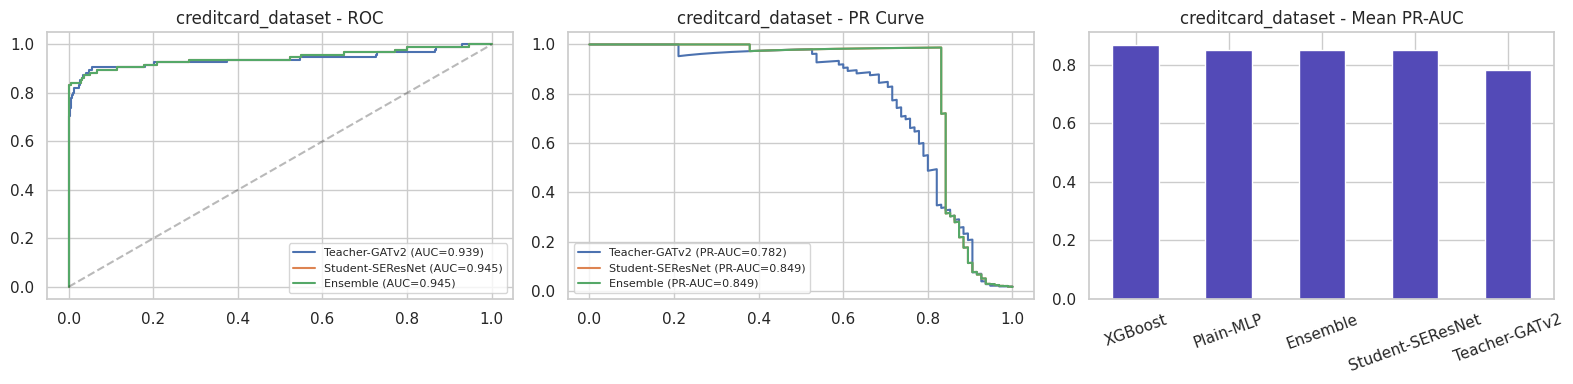

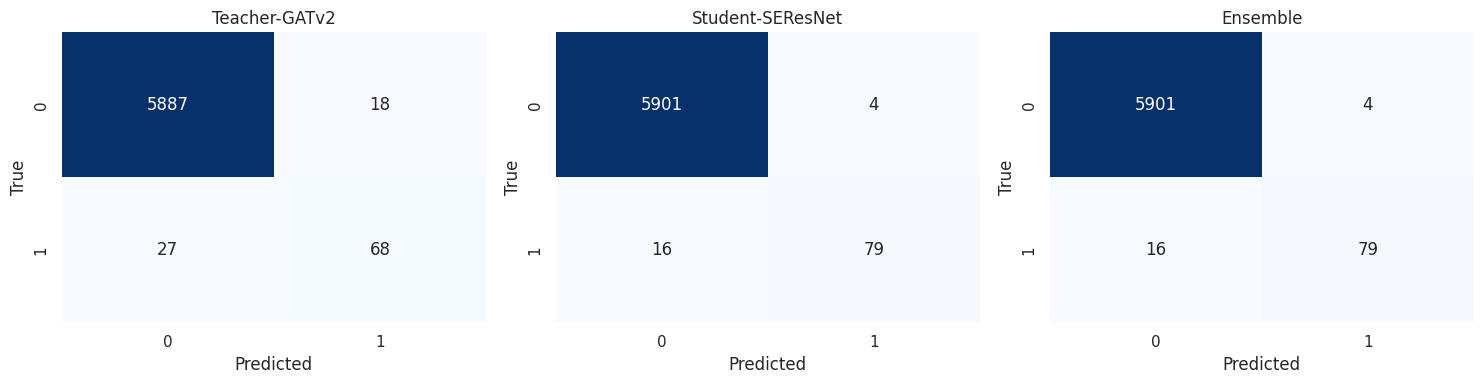


[FAST TOPLINE]
                  PR-AUC  ROC-AUC     MCC  F1-Score  Accuracy
XGBoost           0.8666   0.9606  0.8781    0.8791    0.9963
Plain-MLP         0.8496   0.9463  0.8644    0.8636    0.9960
Ensemble          0.8494   0.9447  0.8880    0.8876    0.9967
Student-SEResNet  0.8494   0.9447  0.8880    0.8876    0.9967
Teacher-GATv2     0.7820   0.9388  0.7485    0.7514    0.9925

[FAST BENCHMARK] Dataset: fraudulent_online_shops

[RUN 1/1] dataset=fraudulent_online_shops seed=0
[SAVED] /content/benchmark_outputs/fraudulent_online_shops/fraudulent_online_shops_fast_summary.csv
[SAVED] /content/benchmark_outputs/fraudulent_online_shops/fraudulent_online_shops_fast_summary_numeric.csv
[SAVED] /content/benchmark_outputs/fraudulent_online_shops/fraudulent_online_shops_fast_latency.csv


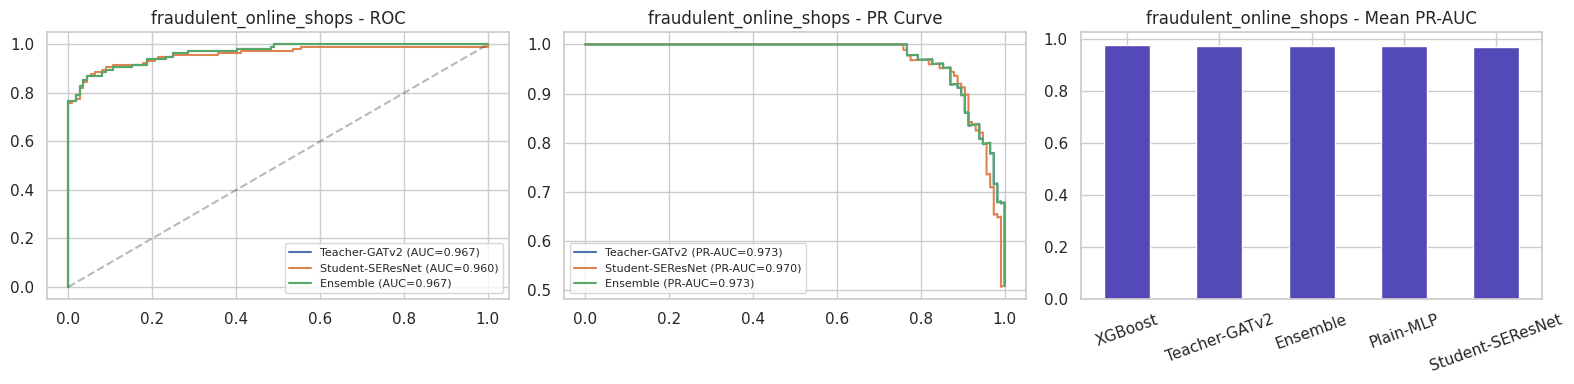

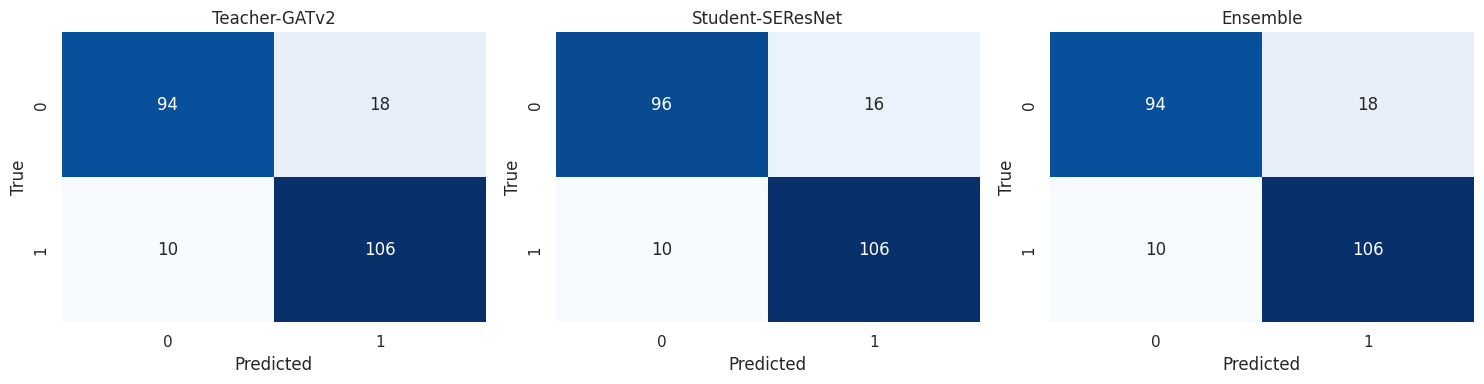


[FAST TOPLINE]
                  PR-AUC  ROC-AUC     MCC  F1-Score  Accuracy
XGBoost           0.9778   0.9736  0.7921    0.9008    0.8947
Teacher-GATv2     0.9731   0.9671  0.7559    0.8833    0.8772
Ensemble          0.9731   0.9671  0.7559    0.8833    0.8772
Plain-MLP         0.9722   0.9654  0.7392    0.8760    0.8684
Student-SEResNet  0.9702   0.9596  0.7727    0.8908    0.8860

[FAST CROSS-DATASET TOPLINE]
                   Dataset BestModel_by_PRAUC  PR-AUC  ROC-AUC     MCC  \
0       creditcard_dataset            XGBoost  0.8666   0.9606  0.8781   
1  fraudulent_online_shops            XGBoost  0.9778   0.9736  0.7921   

   F1-Score  Accuracy  
0    0.8791    0.9963  
1    0.9008    0.8947  

FAST PREVIEW DONE. Outputs saved in: /content/benchmark_outputs


In [ ]:
# ================================================================
# QUICK PATCH — RUN THIS AFTER PART 2
# ================================================================

import time

CONFIG["n_seeds"] = 1
CONFIG["teacher_epochs"] = 150
CONFIG["student_epochs"] = 150
CONFIG["patience"] = 150
CONFIG["batch_size"] = 128
CONFIG["k_neighbors"] = 8

FAST_PREVIEW_MAX_ROWS = {
    "creditcard_dataset": 30000,
    "fraudulent_online_shops": None,
}


def make_fast_bundle(bundle: DatasetBundle, max_rows: Optional[int] = None) -> DatasetBundle:
    if max_rows is None or len(bundle.df) <= max_rows:
        print(f"[FAST MODE] {bundle.name}: using full dataset ({len(bundle.df)} rows)")
        return bundle

    df = bundle.df.copy()
    pos = df[df["y"] == 1]
    neg = df[df["y"] == 0]

    n_neg_keep = max_rows - len(pos)
    n_neg_keep = max(1000, min(n_neg_keep, len(neg)))
    neg_small = neg.sample(n=n_neg_keep, random_state=42)

    df_small = pd.concat([pos, neg_small], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

    print(
        f"[FAST MODE] {bundle.name}: reduced from {len(df)} -> {len(df_small)} rows "
        f"(kept all {len(pos)} fraud rows + sampled {len(neg_small)} non-fraud rows)"
    )

    return DatasetBundle(
        name=bundle.name,
        df=df_small,
        cont_cols=bundle.cont_cols,
        cat_cols=bundle.cat_cols,
        source_path=bundle.source_path,
        label_col_used=bundle.label_col_used,
    )


FAST_DATASET_BUNDLES = []
for b in DATASET_BUNDLES:
    FAST_DATASET_BUNDLES.append(make_fast_bundle(b, FAST_PREVIEW_MAX_ROWS.get(b.name)))

print("\n[FAST PREVIEW READY]")
for b in FAST_DATASET_BUNDLES:
    print(f"- {b.name}: {len(b.df)} rows")


# ================================================================
# FAST PART 3/3 — QUICK PREVIEW BENCHMARK FOR COLAB
# ================================================================

def make_fast_plot_suite(bundle_name, out_dir, summary_numeric, seed_curves, preds_dict):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # ROC
    for name in ["Teacher-GATv2", "Student-SEResNet", "Ensemble"]:
        yt, probs = seed_curves[name]
        fpr, tpr, _ = roc_curve(yt, probs)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(yt, probs):.3f})")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[0].set_title(f"{bundle_name} - ROC")
    axes[0].legend(fontsize=8)

    # PR
    for name in ["Teacher-GATv2", "Student-SEResNet", "Ensemble"]:
        yt, probs = seed_curves[name]
        prec, rec, _ = precision_recall_curve(yt, probs)
        axes[1].plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(yt, probs):.3f})")
    axes[1].set_title(f"{bundle_name} - PR Curve")
    axes[1].legend(fontsize=8)

    # PR-AUC bar
    summary_numeric["PR-AUC"].sort_values(ascending=False).plot(kind="bar", ax=axes[2], color="#534AB7")
    axes[2].set_title(f"{bundle_name} - Mean PR-AUC")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{bundle_name}_fast_plots.png"), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    # Confusion matrices for teacher/student/ensemble
    fig, cm_axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, name in zip(cm_axes, ["Teacher-GATv2", "Student-SEResNet", "Ensemble"]):
        yt, _ = seed_curves[name]
        cm = confusion_matrix(yt, preds_dict[name])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{bundle_name}_fast_confusion_matrices.png"), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def run_fast_benchmark_for_dataset(bundle: DatasetBundle, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)

    all_results = {
        "Teacher-GATv2": [],
        "Student-SEResNet": [],
        "Ensemble": [],
        "XGBoost": [],
        "Plain-MLP": [],
    }
    latency_records = {}
    seed_curves = {}
    preds_dict = {}

    print("\n" + "=" * 100)
    print(f"[FAST BENCHMARK] Dataset: {bundle.name}")
    print("=" * 100)

    for run_i, seed in enumerate(CONFIG["random_seeds"][:CONFIG["n_seeds"]]):
        print(f"\n[RUN {run_i + 1}/{CONFIG['n_seeds']}] dataset={bundle.name} seed={seed}")
        set_seed(seed)
        split = prepare_split(bundle, seed)
        n_feat = split.Xtr.shape[1]

        x_tr, ei_tr, ea_tr, y_g_tr = build_graph(split.Xtr_b, split.Xtr_b, split.ytr_b, k=CONFIG["k_neighbors"], mutual=True)
        x_val, ei_val, ea_val, _ = build_graph(split.Xtr_b, split.Xva, split.yva, k=CONFIG["k_neighbors"], mutual=True)
        x_te, ei_te, ea_te, _ = build_graph(split.Xtr_b, split.Xte, split.yte, k=CONFIG["k_neighbors"], mutual=True)
        offset = len(split.Xtr_b)

        x_tr = x_tr.to(DEVICE)
        ei_tr = ei_tr.to(DEVICE)
        ea_tr = ea_tr.to(DEVICE)
        y_g_tr = y_g_tr.to(DEVICE)
        x_val = x_val.to(DEVICE)
        ei_val = ei_val.to(DEVICE)
        ea_val = ea_val.to(DEVICE)
        x_te = x_te.to(DEVICE)
        ei_te = ei_te.to(DEVICE)
        ea_te = ea_te.to(DEVICE)

        # Teacher
        teacher = TeacherGATv2(n_feat, hidden=64, heads=4, drop=0.2).to(DEVICE)
        teacher, _ = train_graph_model(
            teacher,
            x_tr, ei_tr, ea_tr, y_g_tr,
            x_val, ei_val, ea_val, split.yva,
            offset,
            CONFIG["teacher_epochs"],
            CONFIG["patience"],
        )
        with torch.no_grad():
            t_val_raw = F.softmax(teacher(x_val, ei_val, ea_val)[offset:], dim=-1)[:, 1].cpu().numpy()
            tic = time.perf_counter()
            t_test_raw = F.softmax(teacher(x_te, ei_te, ea_te)[offset:], dim=-1)[:, 1].cpu().numpy()
            t_latency = (time.perf_counter() - tic) / len(split.yte) * 1000
            t_train_logits, t_train_embed = teacher(x_tr, ei_tr, ea_tr, return_embed=True)
            t_train_logits = t_train_logits.detach()
            t_train_embed = t_train_embed.detach()

        # Student
        student = StudentSEResNet(n_feat, hidden=128, drop=0.2, n_blocks=2).to(DEVICE)
        student, _ = train_mlp_model(
            student,
            split.Xtr_b, split.ytr_b,
            split.Xva, split.yva,
            CONFIG["student_epochs"],
            CONFIG["patience"],
            kd_teacher_logits=t_train_logits,
            kd_teacher_embed=t_train_embed,
            use_logit_kd=True,
            use_feature_kd=True,
        )
        Xva_t = torch.tensor(split.Xva, dtype=torch.float32).to(DEVICE)
        Xte_t = torch.tensor(split.Xte, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            s_val_raw = F.softmax(student(Xva_t), dim=-1)[:, 1].cpu().numpy()
            tic = time.perf_counter()
            s_test_raw = F.softmax(student(Xte_t), dim=-1)[:, 1].cpu().numpy()
            s_latency = (time.perf_counter() - tic) / len(split.yte) * 1000

        # Plain MLP
        mlp = PlainMLP(n_feat, hidden=128, drop=0.2).to(DEVICE)
        mlp, _ = train_mlp_model(
            mlp,
            split.Xtr_b, split.ytr_b,
            split.Xva, split.yva,
            CONFIG["student_epochs"],
            CONFIG["patience"],
        )
        with torch.no_grad():
            mlp_val_raw = F.softmax(mlp(Xva_t), dim=-1)[:, 1].cpu().numpy()
            mlp_test_raw = F.softmax(mlp(Xte_t), dim=-1)[:, 1].cpu().numpy()

        # XGBoost
        xgb_model = xgb.XGBClassifier(
            n_estimators=120,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )
        xgb_model.fit(split.Xtr_b, split.ytr_b)
        xgb_val_raw = xgb_model.predict_proba(split.Xva)[:, 1]
        tic = time.perf_counter()
        xgb_test_raw = xgb_model.predict_proba(split.Xte)[:, 1]
        xgb_latency = (time.perf_counter() - tic) / len(split.yte) * 1000

        # Ensemble
        best_w, best_auc_w = 0.5, -np.inf
        for w in np.linspace(0, 1, 11):
            auc = roc_auc_score(split.yva, w * t_val_raw + (1 - w) * s_val_raw)
            if auc > best_auc_w:
                best_auc_w = auc
                best_w = w
        ens_val_raw = best_w * t_val_raw + (1 - best_w) * s_val_raw
        ens_test_raw = best_w * t_test_raw + (1 - best_w) * s_test_raw

        raw_map = {
            "Teacher-GATv2": (t_val_raw, t_test_raw),
            "Student-SEResNet": (s_val_raw, s_test_raw),
            "Ensemble": (ens_val_raw, ens_test_raw),
            "XGBoost": (xgb_val_raw, xgb_test_raw),
            "Plain-MLP": (mlp_val_raw, mlp_test_raw),
        }

        for name, (val_raw, test_raw) in raw_map.items():
            test_cal, preds, _ = calibrate_and_threshold(val_raw, split.yva, test_raw)
            all_results[name].append(profile(split.yte, test_cal, preds))
            if name in ["Teacher-GATv2", "Student-SEResNet", "Ensemble"]:
                preds_dict[name] = preds

        latency_records[seed] = {
            "Teacher-GATv2": t_latency,
            "Student-SEResNet": s_latency,
            "XGBoost": xgb_latency,
        }

        seed_curves = {
            "Teacher-GATv2": (split.yte, t_test_raw),
            "Student-SEResNet": (split.yte, s_test_raw),
            "Ensemble": (split.yte, ens_test_raw),
        }

    summary_rows = []
    for name, runs in all_results.items():
        arr = np.array(runs)
        summary_rows.append([name] + [format_mean_std(arr[:, i]) for i in range(len(METRIC_NAMES))])

    summary_df = pd.DataFrame(summary_rows, columns=["Model"] + METRIC_NAMES).set_index("Model")
    save_dataframe(summary_df, os.path.join(out_dir, f"{bundle.name}_fast_summary.csv"))

    summary_numeric = pd.DataFrame(
        {name: np.array(runs).mean(axis=0) for name, runs in all_results.items()},
        index=METRIC_NAMES,
    ).T
    save_dataframe(summary_numeric, os.path.join(out_dir, f"{bundle.name}_fast_summary_numeric.csv"))

    lat_df = pd.DataFrame(latency_records).T
    save_dataframe(lat_df, os.path.join(out_dir, f"{bundle.name}_fast_latency.csv"))

    make_fast_plot_suite(bundle.name, out_dir, summary_numeric, seed_curves, preds_dict)

    print("\n[FAST TOPLINE]")
    print(summary_numeric.sort_values(by=PRIMARY_METRIC, ascending=False)[["PR-AUC", "ROC-AUC", "MCC", "F1-Score", "Accuracy"]].round(4))

    return {
        "summary_numeric": summary_numeric,
        "summary_text": summary_df,
    }


def build_cross_dataset_report_fast(dataset_results: Dict[str, Dict], out_dir: str):
    rows = []
    for ds_name, result in dataset_results.items():
        summary_numeric = result["summary_numeric"]
        best_model = summary_numeric[PRIMARY_METRIC].idxmax()
        rows.append([
            ds_name,
            best_model,
            summary_numeric.loc[best_model, "PR-AUC"],
            summary_numeric.loc[best_model, "ROC-AUC"],
            summary_numeric.loc[best_model, "MCC"],
            summary_numeric.loc[best_model, "F1-Score"],
            summary_numeric.loc[best_model, "Accuracy"],
        ])

    cross_df = pd.DataFrame(
        rows,
        columns=["Dataset", "BestModel_by_PRAUC", "PR-AUC", "ROC-AUC", "MCC", "F1-Score", "Accuracy"],
    )
    cross_df.to_csv(os.path.join(out_dir, "cross_dataset_fast_topline.csv"), index=False)
    print("\n[FAST CROSS-DATASET TOPLINE]")
    print(cross_df.round(4))
    return cross_df


def main_fast_all_datasets():
    dataset_results = {}

    for bundle in FAST_DATASET_BUNDLES:
        dataset_dir = os.path.join(OUTPUT_DIR, bundle.name)
        os.makedirs(dataset_dir, exist_ok=True)
        result = run_fast_benchmark_for_dataset(bundle, dataset_dir)
        dataset_results[bundle.name] = result

    _ = build_cross_dataset_report_fast(dataset_results, OUTPUT_DIR)

    print("\n" + "=" * 100)
    print(f"FAST PREVIEW DONE. Outputs saved in: {OUTPUT_DIR}")
    print("=" * 100)


# RUN FAST MODE
main_fast_all_datasets()

In [ ]:
# ================================================================
# IMPROVED TEACHER-GATv2 → STUDENT-SE-ResNet KD PIPELINE  (FULLY FIXED)
# ================================================================

# ---- 0. INSTALLS ----
!pip -q install imbalanced-learn xgboost shap torch-geometric lightgbm

# ---- 0b. MEMORY ENV VARS ----
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ---- 1. IMPORTS ----
import glob, zipfile, random, warnings, time, copy, gc
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score, cohen_kappa_score,
    roc_curve, precision_recall_curve, brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE

from imblearn.over_sampling import BorderlineSMOTE, ADASYN
from scipy.stats import ttest_rel, wilcoxon
import xgboost as xgb
import lightgbm as lgb

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False

try:
    from torch_geometric.nn import GATv2Conv, LayerNorm as GeoLayerNorm
except ImportError as e:
    raise ImportError("torch-geometric install failed. Rerun the install cell.") from e

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[SYSTEM] device = {DEVICE}")

# FIX 1: Safely get GPU memory without crashing on different PyTorch versions
if torch.cuda.is_available():
    print(f"[GPU] {torch.cuda.get_device_name(0)}")
    try:
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"[GPU] Total Memory: {gpu_mem:.2f} GB")
    except AttributeError:
        print("[GPU] Memory attribute not found (older PyTorch version), continuing...")

def free_gpu():
    """Aggressively release GPU memory."""
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

# ---- 2. CONFIG ----
OUTPUT_DIR = "/content/benchmark_outputs_v2"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

CONFIG = {
    "n_seeds": 3,
    "teacher_epochs": 180,
    "student_epochs": 200,
    "patience": 30,
    "teacher_lr": 8e-4,
    "student_lr": 1e-3,
    "teacher_wd": 1e-2,
    "student_wd": 5e-4,
    "batch_size": 256,
    "k_neighbors": 8,
    "smote_k_neighbors": 5,
    "smote_m_neighbors": 10,
    "te_splits": 5,
    "target_encoding_smoothing": 10,
    "test_size": 0.20,
    "val_size_within_trainval": 0.20,
    "label_smoothing": 0.05,
    "kd_temperature": 3.5,
    "kd_alpha": 0.45,
    "kd_beta": 0.20,
    "kd_gamma": 0.15,
    "kd_attn": 0.10,
    "focal_gamma": 2.0,
    "class_weight_pos": 50,
    "n_snapshot": 3,
    "random_seeds": [0, 1, 2],
    "teacher_hidden": 64,
    "teacher_heads": 4,
    "teacher_drop": 0.30,
    "max_graph_nodes": 15000,
}

METRIC_NAMES = [
    "Accuracy", "Precision", "Recall", "F1-Score", "F2-Score",
    "ROC-AUC", "PR-AUC", "MCC", "Bal-Acc", "Kappa", "Brier"
]
PRIMARY_METRIC = "PR-AUC"

# ---- 3. DATA BUNDLES ----
@dataclass
class DatasetBundle:
    name: str
    df: pd.DataFrame
    cont_cols: List[str]
    cat_cols: List[str]
    source_path: str
    label_col_used: str

@dataclass
class SplitBundle:
    Xtr: np.ndarray
    ytr: np.ndarray
    Xva: np.ndarray
    yva: np.ndarray
    Xte: np.ndarray
    yte: np.ndarray
    Xtr_b: np.ndarray
    ytr_b: np.ndarray
    feature_names: List[str]
    Xte_orig: np.ndarray

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def save_dataframe(df: pd.DataFrame, out_csv: str):
    df.to_csv(out_csv, index=True)
    print(f"[SAVED] {out_csv}")

def format_mean_std(arr: np.ndarray) -> str:
    return f"{arr.mean():.4f} ± {arr.std(ddof=0):.4f}"

# ---- 4. LOADING + DEEP FEATURE ENGINEERING ----
def extract_csv_if_needed(uploaded_path: str, dataset_name: str) -> str:
    if uploaded_path.lower().endswith(".zip"):
        extract_dir = f"/content/extracted_{dataset_name}"
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(uploaded_path, "r") as z:
            z.extractall(extract_dir)
        csv_files = glob.glob(os.path.join(extract_dir, "**", "*.csv"), recursive=True)
        if not csv_files:
            raise FileNotFoundError(f"No CSV inside zip: {uploaded_path}")
        return csv_files[0]
    return uploaded_path

def detect_label_column(df: pd.DataFrame, preferred: Optional[str] = None) -> str:
    cols = df.columns.tolist()
    lowered = {c.lower(): c for c in cols}
    if preferred and preferred in cols: return preferred
    if preferred and preferred.lower() in lowered: return lowered[preferred.lower()]
    for cand in ["class","label","is_fraud","fraud","target","y","labels"]:
        if cand in lowered: return lowered[cand]
    raise ValueError(f"Could not detect label. Columns: {cols}")

def normalize_binary_target(series: pd.Series) -> pd.Series:
    pos = {"1","true","fraud","fraudulent","yes","positive","fake"}
    return series.astype(str).str.strip().str.lower().isin(pos).astype(int)

def deep_feature_engineer_creditcard(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "Amount" in df.columns:
        df["Amount_log"]   = np.log1p(df["Amount"])
        df["Amount_sqrt"]  = np.sqrt(df["Amount"])
        df["Amount_z"]     = (df["Amount"] - df["Amount"].mean()) / (df["Amount"].std() + 1e-9)
        df["Amount_iszero"] = (df["Amount"] == 0).astype(int)
    if "Time" in df.columns:
        df["Time_hour"]   = (df["Time"] / 3600) % 24
        df["Time_sin"]    = np.sin(2 * np.pi * df["Time_hour"] / 24)
        df["Time_cos"]    = np.cos(2 * np.pi * df["Time_hour"] / 24)
        df["Time_night"]  = ((df["Time_hour"] < 6) | (df["Time_hour"] > 22)).astype(int)
    for a, b in [("V14","V12"), ("V14","V10"), ("V17","V12"), ("V11","V12")]:
        if a in df.columns and b in df.columns:
            df[f"{a}_x_{b}"] = df[a] * df[b]
    return df

def load_uploaded_dataset(uploaded_path, dataset_name, preferred_label=None) -> DatasetBundle:
    drop_tok = ["url","domain_name","shop_name","index","unnamed"]
    csv_path = extract_csv_if_needed(uploaded_path, dataset_name)
    df = pd.read_csv(csv_path)
    print(f"\n[LOAD] {dataset_name} shape={df.shape}")

    label_col = detect_label_column(df, preferred=preferred_label)
    df["y"] = normalize_binary_target(df[label_col])
    df = df.drop(columns=[label_col])

    drop_cols = [c for c in df.columns if any(t in c.lower() for t in drop_tok)]
    df = df.drop(columns=drop_cols, errors="ignore")
    df = df.drop_duplicates().reset_index(drop=True)

    if "creditcard" in dataset_name.lower():
        df = deep_feature_engineer_creditcard(df)

    cont_cols, cat_cols = [], []
    for c in df.columns:
        if c == "y": continue
        if df[c].dtype.kind in "fi" and df[c].nunique(dropna=True) > 10:
            cont_cols.append(c)
        else:
            cat_cols.append(c)

    for c in cont_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())
    for c in cat_cols:
        df[c] = df[c].astype(str).fillna("missing")
        if not df[c].mode().empty:
            df[c] = df[c].replace("nan", df[c].mode()[0])

    print(f"[DATA] {dataset_name} rows={len(df)} fraud_rate={df['y'].mean():.3%} cont={len(cont_cols)} cat={len(cat_cols)}")
    return DatasetBundle(name=dataset_name, df=df, cont_cols=cont_cols,
                         cat_cols=cat_cols, source_path=csv_path, label_col_used=label_col)

# ---- 5. OOF TARGET ENCODING ----
def oof_target_encode(train_df, val_df, test_df, cat_cols, seed, n_splits, smoothing):
    if not cat_cols: return train_df, val_df, test_df
    gm = train_df["y"].mean()
    train_enc, val_enc, test_enc = train_df.copy(), val_df.copy(), test_df.copy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for col in cat_cols:
        oof = np.zeros(len(train_df), dtype=np.float32)
        for tr_idx, ho_idx in skf.split(train_df, train_df["y"]):
            ft = train_df.iloc[tr_idx]
            stats = ft.groupby(col)["y"].agg(["count","mean"])
            mapping = ((stats["count"]*stats["mean"] + smoothing*gm) / (stats["count"] + smoothing)).to_dict()
            oof[ho_idx] = train_df.iloc[ho_idx][col].map(mapping).fillna(gm).values
        train_enc[col] = oof
        full_stats = train_df.groupby(col)["y"].agg(["count","mean"])
        full_map = ((full_stats["count"]*full_stats["mean"] + smoothing*gm) / (full_stats["count"] + smoothing)).to_dict()
        val_enc[col]  = val_df[col].map(full_map).fillna(gm)
        test_enc[col] = test_df[col].map(full_map).fillna(gm)
    return train_enc, val_enc, test_enc

# ---- 6. SPLIT + SMOTE ----
def prepare_split(bundle: DatasetBundle, seed: int) -> SplitBundle:
    df = bundle.df.copy()
    trainval_df, test_df = train_test_split(df, test_size=CONFIG["test_size"], stratify=df["y"], random_state=seed)
    train_df, val_df = train_test_split(trainval_df, test_size=CONFIG["val_size_within_trainval"], stratify=trainval_df["y"], random_state=seed)

    train_df, val_df, test_df = oof_target_encode(train_df, val_df, test_df, bundle.cat_cols, seed, CONFIG["te_splits"], CONFIG["target_encoding_smoothing"])

    feature_names = bundle.cont_cols + bundle.cat_cols
    Xtr_cont = train_df[bundle.cont_cols].values if bundle.cont_cols else np.empty((len(train_df),0))
    Xva_cont = val_df[bundle.cont_cols].values   if bundle.cont_cols else np.empty((len(val_df),0))
    Xte_cont = test_df[bundle.cont_cols].values  if bundle.cont_cols else np.empty((len(test_df),0))

    if Xtr_cont.shape[1] > 0:
        qt = QuantileTransformer(n_quantiles=min(2000, max(1000, len(train_df)//4)), output_distribution="normal", random_state=seed)
        Xtr_cont = qt.fit_transform(Xtr_cont); Xva_cont = qt.transform(Xva_cont); Xte_cont = qt.transform(Xte_cont)

    Xtr_cat = train_df[bundle.cat_cols].values if bundle.cat_cols else np.empty((len(train_df),0))
    Xva_cat = val_df[bundle.cat_cols].values   if bundle.cat_cols else np.empty((len(val_df),0))
    Xte_cat = test_df[bundle.cat_cols].values  if bundle.cat_cols else np.empty((len(test_df),0))

    Xtr = np.hstack([Xtr_cont, Xtr_cat]).astype(np.float32)
    Xva = np.hstack([Xva_cont, Xva_cat]).astype(np.float32)
    Xte = np.hstack([Xte_cont, Xte_cat]).astype(np.float32)
    ytr, yva, yte = train_df["y"].values.astype(int), val_df["y"].values.astype(int), test_df["y"].values.astype(int)

    sm = BorderlineSMOTE(random_state=seed, k_neighbors=CONFIG["smote_k_neighbors"], m_neighbors=CONFIG["smote_m_neighbors"], kind="borderline-1")
    Xtr_b, ytr_b = sm.fit_resample(Xtr, ytr)

    return SplitBundle(Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, Xte=Xte, yte=yte,
                      Xtr_b=Xtr_b.astype(np.float32), ytr_b=ytr_b.astype(int),
                      feature_names=feature_names, Xte_orig=Xte.copy())

# ---- 6b. GRAPH NODE CAP ----
def cap_for_graph(X: np.ndarray, y: np.ndarray, max_nodes: int, seed: int):
    if len(X) <= max_nodes: return X, y
    rng = np.random.RandomState(seed)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_neg_keep = max(0, max_nodes - len(pos_idx))
    if n_neg_keep < len(neg_idx): neg_idx = rng.choice(neg_idx, size=n_neg_keep, replace=False)
    keep = np.concatenate([pos_idx, neg_idx])
    rng.shuffle(keep)
    if len(keep) > max_nodes: keep = keep[:max_nodes]
    print(f"[GRAPH-CAP] {len(X)} -> {len(keep)} nodes")
    return X[keep], y[keep]

# ---- 7. kNN-GRAPH ----
def build_graph(X_anchor, X_query, y_query, k=8, mutual=True):
    engine = NearestNeighbors(n_neighbors=k+1, metric="cosine", n_jobs=-1).fit(X_anchor)
    if X_anchor is X_query:
        dist, idx = engine.kneighbors(X_anchor)
        src = np.repeat(np.arange(len(X_anchor)), k); dst = idx[:, 1:].reshape(-1)
        w = 1.0 / (1.0 + dist[:, 1:].reshape(-1)); cx, cy = X_anchor, y_query
    else:
        qd, qi = engine.kneighbors(X_query, n_neighbors=k); n = len(X_anchor)
        src_q = np.repeat(np.arange(n, n+len(X_query)), k); dst_q = qi.reshape(-1); w_q = 1.0 / (1.0 + qd.reshape(-1))
        td, ti = engine.kneighbors(X_anchor)
        src_t = np.repeat(np.arange(n), k); dst_t = ti[:, 1:].reshape(-1); w_t = 1.0 / (1.0 + td[:, 1:].reshape(-1))
        src = np.concatenate([src_t, src_q]); dst = np.concatenate([dst_t, dst_q]); w = np.concatenate([w_t, w_q])
        cx = np.vstack([X_anchor, X_query]).astype(np.float32); cy = np.concatenate([np.zeros(n, dtype=int), y_query.astype(int)])

    if mutual:
        pairs = set(zip(src.tolist(), dst.tolist()))
        keep = np.array([(d,s) in pairs for s,d in zip(src,dst)])
        if keep.sum() > 100: src, dst, w = src[keep], dst[keep], w[keep]

    us = np.concatenate([src, dst]); ud = np.concatenate([dst, src]); uw = np.concatenate([w, w])
    return (torch.tensor(cx, dtype=torch.float32), torch.tensor(np.vstack([us, ud]), dtype=torch.long),
            torch.tensor(uw, dtype=torch.float32).unsqueeze(1), torch.tensor(cy, dtype=torch.long))

# ---- 8. MODELS ----
# FIX 3: Completely rewritten Teacher to fix 256 vs 64 dimension mismatch and OOM.
# Changed concat=True to concat=False, and fixed skip connection dimensions.
class TeacherGATv2(nn.Module):
    def __init__(self, d_in, hidden=64, heads=4, drop=0.30):
        super().__init__()
        self.g1 = GATv2Conv(d_in, hidden, heads=heads, concat=False, edge_dim=1)
        self.n1 = GeoLayerNorm(hidden)
        self.skip1 = nn.Linear(d_in, hidden)

        self.g2 = GATv2Conv(hidden, hidden, heads=heads, concat=False, edge_dim=1)
        self.n2 = GeoLayerNorm(hidden)
        self.skip2 = nn.Linear(hidden, hidden)  # FIXED: Was previously hidden*heads to hidden causing crash

        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(hidden, 2)

    def forward(self, x, edge_index, edge_attr, return_embed=False):
        h1 = self.drop(F.leaky_relu(self.n1(self.g1(x, edge_index, edge_attr=edge_attr)), 0.1)) + self.skip1(x)
        h2 = self.drop(F.leaky_relu(self.n2(self.g2(h1, edge_index, edge_attr=edge_attr)), 0.1)) + self.skip2(h1)
        logits = self.head(h2)
        if return_embed: return logits, h2
        return logits

class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        h = max(c//r, 4)
        self.fc = nn.Sequential(nn.Linear(c,h), nn.SiLU(), nn.Linear(h,c), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x)

class ResBlock(nn.Module):
    def __init__(self, d, drop=0.2):
        super().__init__()
        self.l1 = nn.Linear(d,d); self.bn1 = nn.BatchNorm1d(d)
        self.l2 = nn.Linear(d,d); self.bn2 = nn.BatchNorm1d(d)
        self.se = SEBlock(d); self.drop = nn.Dropout(drop)
    def forward(self, x):
        h = self.drop(F.silu(self.bn1(self.l1(x))))
        h = self.se(self.bn2(self.l2(h)))
        return F.silu(h + x)

class StudentSEResNet(nn.Module):
    def __init__(self, d_in, hidden=320, drop=0.20, n_blocks=4):
        super().__init__()
        self.proj  = nn.Linear(d_in, hidden)
        self.blocks = nn.ModuleList([ResBlock(hidden, drop) for _ in range(n_blocks)])
        self.bn     = nn.BatchNorm1d(hidden)
        self.head   = nn.Linear(hidden, 2)
        self.attn_proj = nn.Linear(hidden, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x, return_embed=False, return_attn=False):
        h = F.silu(self.proj(x))
        for b in self.blocks: h = b(h)
        emb = self.bn(h)
        logits = self.head(emb)
        if return_attn: return logits, emb, torch.sigmoid(self.attn_proj(emb))
        if return_embed: return logits, emb
        return logits

class PlainMLP(nn.Module):
    def __init__(self, d_in, hidden=256, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, 2))
    def forward(self, x): return self.net(x)

# ---- 9. LOSSES ----
def class_balanced_loss(logits, target, pos_weight=50.0, label_smoothing=0.05, focal_gamma=2.0):
    n_cls = logits.size(1)
    with torch.no_grad():
        true_dist = torch.full_like(logits, label_smoothing/(n_cls-1))
        true_dist.scatter_(1, target.unsqueeze(1), 1.0 - label_smoothing)
    logp = F.log_softmax(logits, dim=-1); p = logp.exp(); focal = (1 - p).pow(focal_gamma)
    ce = -(true_dist * logp).sum(dim=-1)
    w = torch.where(target == 1, pos_weight, 1.0).to(logits.device)
    return ((ce * focal) * w).mean()

# ---- 10. TRAINERS ----
# FIX 2: Enforce device explicitly on inputs to prevent CPU/CUDA mismatches
def train_graph_model(model, x_tr, ei_tr, ea_tr, y_tr, x_val, ei_val, ea_val, y_val_np, offset, epochs, patience, focal=True):
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["teacher_lr"], weight_decay=CONFIG["teacher_wd"])
    sched = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=8)
    scaler = torch.amp.GradScaler('cuda') if DEVICE.type == "cuda" else None

    best_pr, best_state, bad = -np.inf, None, 0
    history = {"loss":[], "val_pr":[]}

    for ep in range(epochs):
        model.train(); opt.zero_grad(set_to_none=True)
        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(x_tr, ei_tr, ea_tr)
                loss = class_balanced_loss(logits, y_tr, pos_weight=CONFIG["class_weight_pos"], label_smoothing=CONFIG["label_smoothing"], focal_gamma=CONFIG["focal_gamma"]) if focal else F.cross_entropy(logits, y_tr, label_smoothing=CONFIG["label_smoothing"])
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update()
        else:
            logits = model(x_tr, ei_tr, ea_tr)
            loss = class_balanced_loss(logits, y_tr, pos_weight=CONFIG["class_weight_pos"], label_smoothing=CONFIG["label_smoothing"], focal_gamma=CONFIG["focal_gamma"]) if focal else F.cross_entropy(logits, y_tr, label_smoothing=CONFIG["label_smoothing"])
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()

        model.eval()
        with torch.inference_mode():
            vout = model(x_val, ei_val, ea_val)
            vprob = F.softmax(vout[offset:], dim=-1)[:,1].float().cpu().numpy()
            pr = average_precision_score(y_val_np, vprob)
        sched.step(pr); history["loss"].append(loss.item()); history["val_pr"].append(pr)
        if pr > best_pr: best_pr, best_state, bad = pr, {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, 0
        else: bad += 1
        del vout, logits, loss
        if bad >= patience: break

    model.load_state_dict(best_state); model.eval(); free_gpu()
    return model, best_pr, history

def train_mlp_model(model, X_tr, y_tr, X_val, y_val, epochs, patience,
                    kd_teacher_logits=None, kd_teacher_embed=None, kd_teacher_attn=None,
                    use_logit_kd=False, use_feature_kd=False, use_relational_kd=False, use_attn_kd=False, snapshot=False):
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["student_lr"], weight_decay=CONFIG["student_wd"])
    sched = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=8)
    Xtr_t, ytr_t = torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long)

    if use_logit_kd or use_feature_kd or use_relational_kd or use_attn_kd:
        items = [Xtr_t, ytr_t]
        if use_logit_kd or use_feature_kd: items += [kd_teacher_logits.cpu(), kd_teacher_embed.cpu()]
        if use_attn_kd: items += [kd_teacher_attn.cpu()]
        dataset = list(zip(*items))
    else:
        dataset = TensorDataset(Xtr_t, ytr_t)

    class_counts = np.bincount(y_tr, minlength=2)
    weights = np.where(y_tr == 1, 1.0/class_counts[1], 1.0/class_counts[0])
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], sampler=sampler)
    Xval_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)

    T, alpha, beta, gamma, attn_w = CONFIG["kd_temperature"], CONFIG["kd_alpha"], CONFIG["kd_beta"], CONFIG["kd_gamma"], CONFIG["kd_attn"]
    best_pr, best_state, bad, snapshot_states = -np.inf, None, 0, []
    history = {"loss":[], "val_pr":[]}

    for ep in range(epochs):
        model.train(); ep_loss, n_b = 0, 0
        for batch in loader:
            opt.zero_grad(set_to_none=True)
            if use_logit_kd or use_feature_kd or use_relational_kd or use_attn_kd:
                xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE); idx = 2
                tlog = temb = tatt = None
                if use_logit_kd or use_feature_kd: tlog, temb = batch[idx].to(DEVICE), batch[idx+1].to(DEVICE); idx += 2
                if use_attn_kd: tatt = batch[idx].to(DEVICE); idx += 1
                out = model(xb, return_embed=True, return_attn=use_attn_kd)
                s_logits, s_emb = (out[0], out[1]) if use_attn_kd else out
                s_attn = out[2] if use_attn_kd else None

                ce = class_balanced_loss(s_logits, yb, pos_weight=CONFIG["class_weight_pos"], label_smoothing=CONFIG["label_smoothing"], focal_gamma=CONFIG["focal_gamma"])
                kd_loss, feat_loss, rel_loss, att_loss = torch.tensor(0., device=DEVICE), torch.tensor(0., device=DEVICE), torch.tensor(0., device=DEVICE), torch.tensor(0., device=DEVICE)
                if use_logit_kd: kd_loss = F.kl_div(F.log_softmax(s_logits/T, dim=-1), F.softmax(tlog/T, dim=-1), reduction="batchmean") * (T**2)
                if use_feature_kd and s_emb.shape == temb.shape: feat_loss = F.mse_loss(s_emb, temb)
                if use_relational_kd and s_emb.shape == temb.shape: rel_loss = F.mse_loss(torch.cdist(s_emb, s_emb, p=2), torch.cdist(temb, temb, p=2).detach())
                if use_attn_kd and tatt is not None: att_loss = F.mse_loss(s_attn, tatt.detach())
                wsum = (alpha if use_logit_kd else 0) + (beta if use_feature_kd else 0) + (gamma if use_relational_kd else 0) + (attn_w if use_attn_kd else 0)
                loss = max(1.0 - wsum, 0.20)*ce + alpha*kd_loss + beta*feat_loss + gamma*rel_loss + attn_w*att_loss
            else:
                xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)
                out = model(xb, return_embed=True, return_attn=False)
                s_logits = out[0] if isinstance(out, tuple) else out
                loss = class_balanced_loss(s_logits, yb, pos_weight=CONFIG["class_weight_pos"], label_smoothing=CONFIG["label_smoothing"], focal_gamma=CONFIG["focal_gamma"])
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            ep_loss += loss.item(); n_b += 1

        model.eval()
        with torch.inference_mode():
            out = model(Xval_t, return_embed=True, return_attn=False)
            vlogits = out[0] if isinstance(out, tuple) else out
            pr = average_precision_score(y_val, F.softmax(vlogits, dim=-1)[:,1].cpu().numpy())
        sched.step(pr); history["loss"].append(ep_loss/max(1,n_b)); history["val_pr"].append(pr)
        if pr > best_pr: best_pr, best_state, bad = pr, {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, 0
        else: bad += 1
        if snapshot and (ep + 1) % max(1, epochs // CONFIG["n_snapshot"]) == 0: snapshot_states.append({k:v.detach().cpu().clone() for k,v in model.state_dict().items()})
        if bad >= patience: break

    model.load_state_dict(best_state); model.eval(); free_gpu()
    return model, best_pr, history, snapshot_states

# ---- 11. THRESHOLD + STACKING ----
def calibrate_and_threshold(val_probs, y_val, test_probs, strategy="f2_recall"):
    cal = LogisticRegression(max_iter=2000).fit(val_probs.reshape(-1,1), y_val)
    val_cal, test_cal = cal.predict_proba(val_probs.reshape(-1,1))[:,1], cal.predict_proba(test_probs.reshape(-1,1))[:,1]
    best_score, best_t = -np.inf, 0.5
    for t in np.linspace(0.05, 0.95, 91):
        pred = (val_cal >= t).astype(int)
        if pred.sum() == 0: continue
        f1, rec, prec = f1_score(y_val, pred, zero_division=0), recall_score(y_val, pred, zero_division=0), precision_score(y_val, pred, zero_division=0)
        score = ((1+4)*prec*rec/(4*prec + rec + 1e-9)) if strategy == "f2" else 4.0 / ((1/(accuracy_score(y_val, pred)+1e-6)) + (1/(f1+1e-6)) + (1/(matthews_corrcoef(y_val, pred)+1.0001)) + (1/(balanced_accuracy_score(y_val, pred)+1e-6)))
        if score > best_score: best_score, best_t = score, t
    return test_cal, (test_cal >= best_t).astype(int), best_t

# ---- 12. PROFILE METRICS ----
def profile(y_true, probs, preds):
    f2 = 0.0
    if preds.sum() > 0:
        p, r = precision_score(y_true, preds, zero_division=0), recall_score(y_true, preds, zero_division=0)
        f2 = (1+4)*p*r/(4*p + r + 1e-9)
    return [accuracy_score(y_true, preds), precision_score(y_true, preds, zero_division=0), recall_score(y_true, preds, zero_division=0), f1_score(y_true, preds, zero_division=0), f2, roc_auc_score(y_true, probs), average_precision_score(y_true, probs), matthews_corrcoef(y_true, preds) if preds.sum() > 0 else 0.0, balanced_accuracy_score(y_true, preds), cohen_kappa_score(y_true, preds), brier_score_loss(y_true, np.clip(probs,1e-6,1-1e-6))]

# ---- 13. EXTRA PLOTS ----
def plot_dataset_distributions(bundle, out_dir):
    df, fr = bundle.df, bundle.df["y"].mean()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].pie([fr, 1-fr], labels=[f"Fraud ({fr:.2%})", f"Non-fraud ({1-fr:.2%})"], colors=["#d62728","#1f77b4"], autopct="", startangle=90)
    axes[0].set_title(f"{bundle.name} — Class balance")
    corrs = {c: abs(df[[c,"y"]].corr().iloc[0,1]) for c in bundle.cont_cols if c in df.columns}
    top = sorted(corrs.items(), key=lambda x: x[1], reverse=True)[:1]
    if top:
        c, _ = top[0]
        sns.kdeplot(df[df["y"]==0][c].dropna(), ax=axes[1], label="non-fraud")
        sns.kdeplot(df[df["y"]==1][c].dropna(), ax=axes[1], label="fraud", color="red")
        axes[1].set_title(f"{c} distribution"); axes[1].legend()
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{bundle.name}_dist.png"), dpi=160, bbox_inches="tight"); plt.show(); plt.close()

def plot_learning_curves(ht, hs, out_path, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(ht["loss"], label="teacher-loss", color="tab:orange"); ax[0].set_title(f"{title} — Teacher loss"); ax[0].legend()
    ax[1].plot(hs["loss"], label="student-loss", color="tab:blue"); ax[1].plot(hs["val_pr"], label="student val PR-AUC", color="tab:green"); ax[1].set_title(f"{title} — Student"); ax[1].legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=160, bbox_inches="tight"); plt.show(); plt.close()

# ---- 14. MAIN RUN ----
def run_benchmark_for_dataset(bundle, out_dir):
    os.makedirs(out_dir, exist_ok=True); plot_dataset_distributions(bundle, out_dir)
    all_results = {k: [] for k in ["Teacher-GATv2","Student-SEResNet","Student-Snapshot","Ensemble-Stacking","XGBoost","LightGBM","Plain-MLP"]}
    latency_records, seed_curves, preds_dict, last_models = {}, {}, {}, {}
    print("\n" + "="*100 + f"\n[BENCHMARK] Dataset: {bundle.name}\n" + "="*100)

    for run_i, seed in enumerate(CONFIG["random_seeds"][:CONFIG["n_seeds"]]):
        print(f"\n[RUN {run_i+1}/{CONFIG['n_seeds']}] seed={seed}"); set_seed(seed); free_gpu()
        split = prepare_split(bundle, seed); n_feat = split.Xtr.shape[1]
        Xg_tr, yg_tr = cap_for_graph(split.Xtr_b, split.ytr_b, CONFIG["max_graph_nodes"], seed)

        x_tr, ei_tr, ea_tr, y_g_tr = build_graph(Xg_tr, Xg_tr, yg_tr, k=CONFIG["k_neighbors"], mutual=True)
        x_val, ei_val, ea_val, _    = build_graph(Xg_tr, split.Xva, split.yva, k=CONFIG["k_neighbors"], mutual=True)
        x_te, ei_te, ea_te, _       = build_graph(Xg_tr, split.Xte, split.yte, k=CONFIG["k_neighbors"], mutual=True)
        offset = len(Xg_tr)

        # FIX 2: Strict device movement
        x_tr, ei_tr, ea_tr, y_g_tr = x_tr.to(DEVICE), ei_tr.to(DEVICE), ea_tr.to(DEVICE), y_g_tr.to(DEVICE)
        x_val, ei_val, ea_val = x_val.to(DEVICE), ei_val.to(DEVICE), ea_val.to(DEVICE)
        x_te, ei_te, ea_te = x_te.to(DEVICE), ei_te.to(DEVICE), ea_te.to(DEVICE)

        teacher = TeacherGATv2(n_feat, hidden=CONFIG["teacher_hidden"], heads=CONFIG["teacher_heads"], drop=CONFIG["teacher_drop"]).to(DEVICE)
        teacher, _, hist_t = train_graph_model(teacher, x_tr, ei_tr, ea_tr, y_g_tr, x_val, ei_val, ea_val, split.yva, offset, CONFIG["teacher_epochs"], CONFIG["patience"], focal=True)

        with torch.inference_mode():
            t_val_raw = F.softmax(teacher(x_val, ei_val, ea_val)[offset:], dim=-1)[:,1].cpu().numpy()
            tic = time.perf_counter(); t_test_raw = F.softmax(teacher(x_te, ei_te, ea_te)[offset:], dim=-1)[:,1].cpu().numpy(); t_latency = (time.perf_counter()-tic)/len(split.yte)*1000
            t_train_logits, t_train_embed = teacher(x_tr, ei_tr, ea_tr, return_embed=True)
            t_train_logits, t_train_embed, t_train_attn = t_train_logits.detach(), t_train_embed.detach(), t_train_embed.norm(dim=-1, keepdim=True).detach()

        del x_val, ei_val, ea_val, x_te, ei_te, ea_te; free_gpu()

        student = StudentSEResNet(n_feat, hidden=320, drop=0.20, n_blocks=4).to(DEVICE)
        student, _, hist_s, snapshots = train_mlp_model(student, Xg_tr, yg_tr, split.Xva, split.yva, CONFIG["student_epochs"], CONFIG["patience"], kd_teacher_logits=t_train_logits, kd_teacher_embed=t_train_embed, kd_teacher_attn=t_train_attn, use_logit_kd=True, use_feature_kd=True, use_relational_kd=True, use_attn_kd=True, snapshot=True)
        Xva_t, Xte_t = torch.tensor(split.Xva, dtype=torch.float32).to(DEVICE), torch.tensor(split.Xte, dtype=torch.float32).to(DEVICE)

        with torch.inference_mode():
            s_val_raw = F.softmax(student(Xva_t), dim=-1)[:,1].cpu().numpy()
            tic = time.perf_counter(); s_test_raw = F.softmax(student(Xte_t), dim=-1)[:,1].cpu().numpy(); s_latency = (time.perf_counter()-tic)/len(split.yte)*1000

        del x_tr, ei_tr, ea_tr, y_g_tr, t_train_logits, t_train_embed, t_train_attn; free_gpu()

        snap_probs_va, snap_probs_te = [], []
        for st in snapshots:
            student.load_state_dict(st); student.eval()
            with torch.inference_mode():
                snap_probs_va.append(F.softmax(student(Xva_t), dim=-1)[:,1].cpu().numpy())
                snap_probs_te.append(F.softmax(student(Xte_t), dim=-1)[:,1].cpu().numpy())
        snap_val_raw = np.mean(snap_probs_va, axis=0) if snap_probs_va else s_val_raw
        snap_test_raw = np.mean(snap_probs_te, axis=0) if snap_probs_te else s_test_raw

        mlp = PlainMLP(n_feat, hidden=256, drop=0.2).to(DEVICE)
        mlp, _, _, _ = train_mlp_model(mlp, split.Xtr_b, split.ytr_b, split.Xva, split.yva, CONFIG["student_epochs"], CONFIG["patience"])
        with torch.inference_mode(): mlp_val_raw, mlp_test_raw = F.softmax(mlp(Xva_t), dim=-1)[:,1].cpu().numpy(), F.softmax(mlp(Xte_t), dim=-1)[:,1].cpu().numpy()
        del Xva_t, Xte_t; free_gpu()

        xgb_model = xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, scale_pos_weight=CONFIG["class_weight_pos"], min_child_weight=2, gamma=0.1, reg_alpha=0.1, reg_lambda=1.0, random_state=seed, eval_metric="aucpr", n_jobs=-1, tree_method="hist", device="cuda" if DEVICE.type=="cuda" else "cpu")
        xgb_model.fit(split.Xtr_b, split.ytr_b, eval_set=[(split.Xva, split.yva)], verbose=False)
        xgb_val_raw = xgb_model.predict_proba(split.Xva)[:,1]; tic = time.perf_counter(); xgb_test_raw = xgb_model.predict_proba(split.Xte)[:,1]; xgb_latency = (time.perf_counter()-tic)/len(split.yte)*1000

        lgb_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=-1, num_leaves=63, subsample=0.85, colsample_bytree=0.85, min_child_samples=10, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=CONFIG["class_weight_pos"], random_state=seed, n_jobs=-1, verbose=-1)
        lgb_model.fit(split.Xtr_b, split.ytr_b, eval_set=[(split.Xva, split.yva)], callbacks=[lgb.early_stopping(30, verbose=False)])
        lgb_val_raw = lgb_model.predict_proba(split.Xva)[:,1]; tic = time.perf_counter(); lgb_test_raw = lgb_model.predict_proba(split.Xte)[:,1]; lgb_latency = (time.perf_counter()-tic)/len(split.yte)*1000

        meta_val, meta_test = np.vstack([t_val_raw, s_val_raw, snap_val_raw, xgb_val_raw, lgb_val_raw, mlp_val_raw]).T, np.vstack([t_test_raw, s_test_raw, snap_test_raw, xgb_test_raw, lgb_test_raw, mlp_test_raw]).T
        meta_clf = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0).fit(meta_val, split.yva)
        ens_val_raw, ens_test_raw = meta_clf.predict_proba(meta_val)[:,1], meta_clf.predict_proba(meta_test)[:,1]

        raw_map = {"Teacher-GATv2": (t_val_raw, t_test_raw), "Student-SEResNet": (s_val_raw, s_test_raw), "Student-Snapshot": (snap_val_raw, snap_test_raw), "Ensemble-Stacking": (ens_val_raw, ens_test_raw), "XGBoost": (xgb_val_raw, xgb_test_raw), "LightGBM": (lgb_val_raw, lgb_test_raw), "Plain-MLP": (mlp_val_raw, mlp_test_raw)}
        for name, (val_raw, test_raw) in raw_map.items():
            test_cal, preds, _ = calibrate_and_threshold(val_raw, split.yva, test_raw, strategy="f2")
            all_results[name].append(profile(split.yte, test_cal, preds))
            if name in ["Teacher-GATv2","Student-SEResNet","Ensemble-Stacking","Student-Snapshot"]: preds_dict[name] = preds
        latency_records[seed] = {"Teacher-GATv2": t_latency, "Student-SEResNet": s_latency, "XGBoost": xgb_latency, "LightGBM": lgb_latency}
        seed_curves = {"Teacher-GATv2": (split.yte, t_test_raw), "Student-SEResNet": (split.yte, s_test_raw), "Ensemble-Stacking": (split.yte, ens_test_raw)}
        plot_learning_curves(hist_t, hist_s, os.path.join(out_dir, f"{bundle.name}_lc_seed{seed}.png"), f"{bundle.name} seed={seed}")
        if last_models: [del m for m in last_models.values()]
        last_models = dict(teacher=teacher, student=student, mlp=mlp); free_gpu()

    summary_rows = []
    for name, runs in all_results.items():
        arr = np.array(runs); summary_rows.append([name] + [format_mean_std(arr[:,i]) for i in range(len(METRIC_NAMES))])
    summary_df = pd.DataFrame(summary_rows, columns=["Model"]+METRIC_NAMES).set_index("Model")
    save_dataframe(summary_df, os.path.join(out_dir, f"{bundle.name}_summary.csv"))
    summary_numeric = pd.DataFrame({name: np.array(runs).mean(axis=0) for name, runs in all_results.items()}, index=METRIC_NAMES).T
    save_dataframe(summary_numeric, os.path.join(out_dir, f"{bundle.name}_summary_numeric.csv"))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for name, (yt, probs) in seed_curves.items():
        fpr, tpr, _ = roc_curve(yt, probs); axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(yt,probs):.3f})")
    axes[0].plot([0,1],[0,1],"k--",alpha=0.3); axes[0].set_title(f"{bundle.name} — ROC"); axes[0].legend(fontsize=8)
    for name, (yt, probs) in seed_curves.items():
        prec, rec, _ = precision_recall_curve(yt, probs); axes[1].plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(yt,probs):.3f})")
    axes[1].set_title(f"{bundle.name} — PR"); axes[1].legend(fontsize=8)
    summary_numeric["PR-AUC"].sort_values(ascending=False).plot(kind="bar", ax=axes[2], color="#534AB7")
    axes[2].set_title(f"{bundle.name} — Mean PR-AUC"); axes[2].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{bundle.name}_roc_pr.png"), dpi=180, bbox_inches="tight"); plt.show()

    print("\n" + "="*70); print(f"[RESULTS] {bundle.name}"); print("="*70)
    print(summary_numeric.sort_values(by=PRIMARY_METRIC, ascending=False)[["PR-AUC", "ROC-AUC", "MCC", "F1-Score", "Recall"]].round(4))
    return {"summary_numeric": summary_numeric}

def make_fast_bundle(bundle, max_rows):
    if max_rows is None or len(bundle.df) <= max_rows: return bundle
    pos, neg = bundle.df[bundle.df["y"] == 1], bundle.df[bundle.df["y"] == 0]
    neg_small = neg.sample(n=max(2000, max_rows - len(pos)), random_state=42)
    df_small = pd.concat([pos, neg_small]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"[FAST MODE] {bundle.name}: {len(bundle.df)} -> {len(df_small)} rows")
    return DatasetBundle(name=bundle.name, df=df_small, cont_cols=bundle.cont_cols, cat_cols=bundle.cat_cols, source_path=bundle.source_path, label_col_used=bundle.label_col_used)

def main():
    print("\nUpload 1/2: creditcard.csv.zip"); up1 = files.upload(); file1 = f"/content/{list(up1.keys())[0]}"
    print("\nUpload 2/2: Fraudulent_online_shops_dataset (1).csv"); up2 = files.upload(); file2 = f"/content/{list(up2.keys())[0]}"
    bundles = [make_fast_bundle(load_uploaded_dataset(file1, "creditcard_dataset", "Class"), 35000),
               make_fast_bundle(load_uploaded_dataset(file2, "fraudulent_online_shops"), None)]
    dataset_results = {}
    for b in bundles:
        dataset_results[b.name] = run_benchmark_for_dataset(b, os.path.join(OUTPUT_DIR, b.name)); free_gpu()
    print("\n" + "="*80 + f"\nDONE. Outputs: {OUTPUT_DIR}\n" + "="*80)

if __name__ == "__main__":
    main()

SyntaxError: invalid syntax (4064042245.py, line 637)